In [1]:
import pandas as pd


link="https://github.com/PoliticayGobiernoPUCP/Gob_TomaDeDecisiones/raw/refs/heads/master/dataCrim.xlsx"
crim=pd.read_excel(link,dtype={'cod': str})
crim.head()

,dep,prov,cod,distrito,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AMAZONAS,BAGUA,010201,BAGUA,247.0,193.0,50.0,19.0,109.0,61.0,71.0,91.0,64.0,75.0
1,AMAZONAS,NaN,010202,ARAMANGO,16.0,36.0,50.0,65.0,70.0,35.0,51.0,65.0,48.0,29.0
2,AMAZONAS,NaN,010203,COPALLIN,1.0,23.0,54.0,60.0,51.0,47.0,27.0,17.0,23.0,34.0
3,AMAZONAS,NaN,010204,EL PARCO,2.0,1.0,NaN,4.0,5.0,5.0,10.0,4.0,33.0,8.0
4,AMAZONAS,NaN,010205,IMAZA,58.0,72.0,58.0,92.0,115.0,100.0,138.0,101.0,74.0,82.0


In [2]:
crim.columns=[str(c) for c in crim.columns]

In [3]:
crim['prov']=crim.prov.ffill()

In [4]:
crim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1858 entries, 0 to 1857
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   dep       1858 non-null   object 
 1   prov      1858 non-null   object 
 2   cod       1858 non-null   object 
 3   distrito  1858 non-null   object 
 4   2015      1509 non-null   float64
 5   2016      1516 non-null   float64
 6   2017      1633 non-null   float64
 7   2018      1600 non-null   float64
 8   2019      1505 non-null   float64
 9   2020      1590 non-null   float64
 10  2021      1667 non-null   float64
 11  2022      1668 non-null   float64
 12  2023      1671 non-null   float64
 13  2024      1617 non-null   float64
dtypes: float64(10), object(4)
memory usage: 203.3+ KB


In [5]:
crim.replace({'dep':{'LIMA METROPOLITANA':'LIMA'}},inplace=True)

In [6]:
import geopandas as gpd

dis=gpd.read_file('DISTRITOS1874.shp')
dis.head()

,DEPARTAMEN,PROVINCIA,DISTRITO,INSTITUCIO,geometry
0,TACNA,TACNA,CORONEL GREGORIO ALBARRACIN LANCHIPA,IGN,"POLYGON ((-70.17413 -18.12896, -70.17461 -18.1..."
1,TACNA,TACNA,POCOLLAY,IGN,"POLYGON ((-69.93475 -17.92557, -69.90467 -17.9..."
2,TACNA,TACNA,CALANA,IGN,"POLYGON ((-70.11604 -17.91106, -70.11457 -17.9..."
3,TACNA,TACNA,TACNA,IGN,"POLYGON ((-70.31490 -17.94498, -70.30682 -17.9..."
4,TACNA,TACNA,SAMA,IGN,"POLYGON ((-70.42497 -17.88934, -70.48022 -17.9..."


In [7]:
from unidecode import unidecode

dis['DISTRITO']=dis.DISTRITO.apply(unidecode)
crim['distrito']= crim.distrito.apply(unidecode)
    


In [8]:
colsCrim=['dep','prov','distrito']
colsDis=['DEPARTAMEN','PROVINCIA','DISTRITO']
concatRowVals=lambda row: '_'.join(row.values.astype(str))
crim['merger']=crim[colsCrim].apply(concatRowVals, axis=1)
dis['merger']=dis[colsDis].apply(concatRowVals, axis=1)

In [9]:
onlyCrim=set(crim.merger) - set(dis.merger)
onlyCrim

{'APURIMAC_AYMARAES_CARAYBAMBA',
 'APURIMAC_CHINCHEROS_ANCO_HUALLO',
 'AREQUIPA_CAMANA_CAMANA',
 'AREQUIPA_CAMANA_MARIANO NICOLAS VALCARCEL',
 'AYACUCHO_HUAMANGA_SAN JOSE DE TICLLAS',
 'AYACUCHO_VILCAS HUAMAN_ACCOMARCA',
 'AYACUCHO_VILCAS HUAMAN_CARHUANCA',
 'AYACUCHO_VILCAS HUAMAN_CONCEPCION',
 'AYACUCHO_VILCAS HUAMAN_HUAMBALPA',
 'AYACUCHO_VILCAS HUAMAN_INDEPENDENCIA',
 'AYACUCHO_VILCAS HUAMAN_SAURAMA',
 'AYACUCHO_VILCAS HUAMAN_VILCAS HUAMAN',
 'AYACUCHO_VILCAS HUAMAN_VISCHONGO',
 'CAJAMARCA_CONTUMAZA_SANTA CRUZ DE TOLEDO',
 'CAJAMARCA_JAEN_PUCARA',
 'CUSCO_ACOMAYO_SANGARARA',
 'HUANCAVELICA_ANGARAES_HUANCA-HUANCA',
 'HUANCAVELICA_ANGARAES_HUAYLLAY GRANDE',
 'HUANCAVELICA_CASTROVIRREYNA_TANTARA',
 'HUANUCO_HUANUCO_QUISQUI (KICHKI)',
 'HUANUCO_MARAяN_CHOLON',
 'HUANUCO_MARAяN_HUACRACHUCO',
 'HUANUCO_MARAяN_LA MORADA',
 'HUANUCO_MARAяN_SAN BUENAVENTURA',
 'HUANUCO_MARAяN_SANTA ROSA DE ALTO YANAJANCA',
 'ICA_ICA_SAN JOSE DE LOS MOLINOS',
 'ICA_NASCA_CHANGUILLO',
 'ICA_NASCA_EL INGENIO',

In [10]:
onlyDis=set(dis.merger)-set(crim.merger)
onlyDis

{'ANCASH_AIJA_HUACLLAN',
 'ANCASH_BOLOGNESI_CANIS',
 'APURIMAC_AYMARAES_CARAIBAMBA',
 'APURIMAC_CHINCHEROS_ANCO HUALLO',
 'APURIMAC_CHINCHEROS_EL PORVENIR',
 'APURIMAC_CHINCHEROS_LOS CHANKAS',
 'AREQUIPA_CAMANA_CAMANA ',
 'AREQUIPA_CAMANA_MARIANO NICOLAS VALCaRCEL',
 'AYACUCHO_HUAMANGA_SAN JOSE  DE TICLLAS',
 'AYACUCHO_LA MAR_ORONCCOY',
 'AYACUCHO_VILCAS-HUAMAN_ACCOMARCA',
 'AYACUCHO_VILCAS-HUAMAN_CARHUANCA',
 'AYACUCHO_VILCAS-HUAMAN_CONCEPCION',
 'AYACUCHO_VILCAS-HUAMAN_HUAMBALPA',
 'AYACUCHO_VILCAS-HUAMAN_INDEPENDENCIA',
 'AYACUCHO_VILCAS-HUAMAN_SAURAMA',
 'AYACUCHO_VILCAS-HUAMAN_VILCAS HUAMAN',
 'AYACUCHO_VILCAS-HUAMAN_VISCHONGO',
 'CAJAMARCA_CONTUMAZA_SANTA CRUZ DE TOLED',
 'CAJAMARCA_JAEN_PUCARA ',
 'CUSCO_ACOMAYO_SANGARARA ',
 'HUANCAVELICA_ANGARAES_HUALLAY GRANDE',
 'HUANCAVELICA_ANGARAES_HUANCA HUANCA',
 'HUANCAVELICA_CASTROVIRREYNA_TANTARA ',
 'HUANCAVELICA_HUAYTARA_SAN ISIDRO',
 'HUANCAVELICA_TAYACAJA_SANTIAGO DE TUCUMA',
 'HUANUCO_HUANUCO_QUISQUI',
 'HUANUCO_MARAÑON_CHOLON',

In [11]:
from thefuzz.process import extractOne as getBest
[(c,getBest(c,onlyDis)) for c in onlyCrim]

[('AYACUCHO_VILCAS HUAMAN_CONCEPCION',
  ('AYACUCHO_VILCAS-HUAMAN_CONCEPCION', 100)),
 ('AYACUCHO_VILCAS HUAMAN_CARHUANCA',
  ('AYACUCHO_VILCAS-HUAMAN_CARHUANCA', 100)),
 ('CAJAMARCA_CONTUMAZA_SANTA CRUZ DE TOLEDO',
  ('CAJAMARCA_CONTUMAZA_SANTA CRUZ DE TOLED', 99)),
 ('AREQUIPA_CAMANA_CAMANA', ('AREQUIPA_CAMANA_CAMANA ', 100)),
 ('AYACUCHO_VILCAS HUAMAN_INDEPENDENCIA',
  ('AYACUCHO_VILCAS-HUAMAN_INDEPENDENCIA', 100)),
 ('SAN MARTIN_SAN MARTIN_PAPAPLAYA', ('SAN MARTIN_SAN MARTIN_PAPA-PLAYA', 98)),
 ('HUANUCO_MARAяN_LA MORADA', ('HUANUCO_MARAÑON_LA MORADA', 96)),
 ('LA LIBERTAD_VIRU_VIRU', ('LA LIBERTAD_VIRÚ_VIRU', 98)),
 ('LA LIBERTAD_GRAN CHIMU_MARMOT', ('LA LIBERTAD_GRAN CHIMÚ_MARMOT', 98)),
 ('TACNA_TARATA_ESTIQUE-PAMPA', ('TACNA_TARATA_ESTIQUE PAMPA', 100)),
 ('CUSCO_ACOMAYO_SANGARARA', ('CUSCO_ACOMAYO_SANGARARA ', 100)),
 ('LIMA_CAхTE_SAN LUIS', ('LIMA_CAÑETE_SAN LUIS', 95)),
 ('ICA_NASCA_VISTA ALEGRE', ('ICA_NAZCA_VISTA ALEGRE', 95)),
 ('AYACUCHO_VILCAS HUAMAN_VILCAS HUAMAN',
  (

In [12]:
changesDis={getBest(c,onlyDis)[0]:c for c in onlyCrim if getBest(c,onlyDis)[1]==100}
changesDis

{'AYACUCHO_VILCAS-HUAMAN_CONCEPCION': 'AYACUCHO_VILCAS HUAMAN_CONCEPCION',
 'AYACUCHO_VILCAS-HUAMAN_CARHUANCA': 'AYACUCHO_VILCAS HUAMAN_CARHUANCA',
 'AREQUIPA_CAMANA_CAMANA ': 'AREQUIPA_CAMANA_CAMANA',
 'AYACUCHO_VILCAS-HUAMAN_INDEPENDENCIA': 'AYACUCHO_VILCAS HUAMAN_INDEPENDENCIA',
 'TACNA_TARATA_ESTIQUE PAMPA': 'TACNA_TARATA_ESTIQUE-PAMPA',
 'CUSCO_ACOMAYO_SANGARARA ': 'CUSCO_ACOMAYO_SANGARARA',
 'AYACUCHO_VILCAS-HUAMAN_VILCAS HUAMAN': 'AYACUCHO_VILCAS HUAMAN_VILCAS HUAMAN',
 'PIURA_SECHURA_RINCONADA-LLICUAR': 'PIURA_SECHURA_RINCONADA LLICUAR',
 'AYACUCHO_VILCAS-HUAMAN_ACCOMARCA': 'AYACUCHO_VILCAS HUAMAN_ACCOMARCA',
 'JUNIN_YAULI_SANTA BARBARA DE CARHUACAYaN': 'JUNIN_YAULI_SANTA BARBARA DE CARHUACAYAN',
 'AYACUCHO_VILCAS-HUAMAN_HUAMBALPA': 'AYACUCHO_VILCAS HUAMAN_HUAMBALPA',
 'PUNO_LAMPA_PUCARA ': 'PUNO_LAMPA_PUCARA',
 'HUANCAVELICA_ANGARAES_HUANCA HUANCA': 'HUANCAVELICA_ANGARAES_HUANCA-HUANCA',
 'SAN MARTIN_PICOTA_TRES-UNIDOS': 'SAN MARTIN_PICOTA_TRES UNIDOS',
 'AYACUCHO_VILCAS-HUAMA

In [13]:
dis.replace({'merger':changesDis},inplace=True)

In [14]:
onlyCrim=set(crim.merger) - set(dis.merger)
onlyDis=set(dis.merger)-set(crim.merger)
[(c,getBest(c,onlyDis)) for c in onlyCrim]

[('LORETO_DATEM DEL MARAяN_BARRANCA',
  ('LORETO_DATEM DEL MARAÑON_BARRANCA', 97)),
 ('LIMA_CAхTE_SAN LUIS', ('LIMA_CAÑETE_SAN LUIS', 95)),
 ('AYACUCHO_HUAMANGA_SAN JOSE DE TICLLAS',
  ('AYACUCHO_HUAMANGA_SAN JOSE  DE TICLLAS', 99)),
 ('ICA_NASCA_VISTA ALEGRE', ('ICA_NAZCA_VISTA ALEGRE', 95)),
 ('ICA_NASCA_NASCA', ('ICA_NAZCA_NAZCA', 87)),
 ('LIMA_CAхTE_SANTA CRUZ DE FLORES', ('LIMA_CAÑETE_SANTA CRUZ DE FLORES', 97)),
 ('LAMBAYEQUE_FERREсFE_CANARIS', ('LAMBAYEQUE_FERREÑAFE_CANARIS', 96)),
 ('HUANUCO_MARAяN_SANTA ROSA DE ALTO YANAJANCA',
  ('HUANUCO_MARAÑON_SANTA ROSA DE ALTO YANAJANCA', 98)),
 ('LIMA_YAUYOS_ALLAUCA', ('LIMA_YAUYOS_AYAUCA', 92)),
 ('LAMBAYEQUE_FERREсFE_PITIPO', ('LAMBAYEQUE_FERREÑAFE_PITIPO', 96)),
 ('JUNIN_CHUPACA_SAN JUAN DE ISCOS', ('JUNIN_CHUPACA_SAN JUAN DE YSCOS', 97)),
 ('UCAYALI_PURUS_PURUS', ('UCAYALI_PURÚS_PURUS', 97)),
 ('APURIMAC_CHINCHEROS_ANCO_HUALLO', ('APURIMAC_CHINCHEROS_ANCO HUALLO', 97)),
 ('LIMA_CAхTE_LUNAHUANA', ('LIMA_CAÑETE_LUNAHUANA ', 95)),
 ('L

In [15]:
changesCrim={c:getBest(c,onlyDis)[0] for c in onlyCrim if getBest(c,onlyDis)[1]>=90}
changesCrim

{'LORETO_DATEM DEL MARAяN_BARRANCA': 'LORETO_DATEM DEL MARAÑON_BARRANCA',
 'LIMA_CAхTE_SAN LUIS': 'LIMA_CAÑETE_SAN LUIS',
 'AYACUCHO_HUAMANGA_SAN JOSE DE TICLLAS': 'AYACUCHO_HUAMANGA_SAN JOSE  DE TICLLAS',
 'ICA_NASCA_VISTA ALEGRE': 'ICA_NAZCA_VISTA ALEGRE',
 'LIMA_CAхTE_SANTA CRUZ DE FLORES': 'LIMA_CAÑETE_SANTA CRUZ DE FLORES',
 'LAMBAYEQUE_FERREсFE_CANARIS': 'LAMBAYEQUE_FERREÑAFE_CANARIS',
 'HUANUCO_MARAяN_SANTA ROSA DE ALTO YANAJANCA': 'HUANUCO_MARAÑON_SANTA ROSA DE ALTO YANAJANCA',
 'LIMA_YAUYOS_ALLAUCA': 'LIMA_YAUYOS_AYAUCA',
 'LAMBAYEQUE_FERREсFE_PITIPO': 'LAMBAYEQUE_FERREÑAFE_PITIPO',
 'JUNIN_CHUPACA_SAN JUAN DE ISCOS': 'JUNIN_CHUPACA_SAN JUAN DE YSCOS',
 'UCAYALI_PURUS_PURUS': 'UCAYALI_PURÚS_PURUS',
 'APURIMAC_CHINCHEROS_ANCO_HUALLO': 'APURIMAC_CHINCHEROS_ANCO HUALLO',
 'LIMA_CAхTE_LUNAHUANA': 'LIMA_CAÑETE_LUNAHUANA ',
 'LIMA_CAхTE_IMPERIAL': 'LIMA_CAÑETE_IMPERIAL',
 'LORETO_DATEM DEL MARAяN_PASTAZA': 'LORETO_DATEM DEL MARAÑON_PASTAZA',
 'HUANUCO_MARAяN_HUACRACHUCO': 'HUANUCO_M

In [16]:
crim.replace({'merger':changesCrim},inplace=True)
onlyCrim=set(crim.merger) - set(dis.merger)
onlyDis=set(dis.merger)-set(crim.merger)
[(c,getBest(c,onlyDis)) for c in onlyCrim]

[('LIMA_LIMA_PUEBLO LIBRE', ('LIMA_LIMA_MAGDALENA VIEJA', 60)),
 ('ICA_NASCA_NASCA', ('ICA_NAZCA_NAZCA', 87))]

In [17]:
handy={'LIMA_LIMA_MAGDALENA VIEJA':'LIMA_LIMA_PUEBLO LIBRE','ICA_NAZCA_NAZCA':'ICA_NASCA_NASCA'}
dis.replace({'merger':handy},inplace=True)
onlyCrim=set(crim.merger) - set(dis.merger)
onlyDis=set(dis.merger)-set(crim.merger)
[(c,getBest(c,onlyDis)) for c in onlyCrim]

[]

In [18]:
discrim=dis.merge(crim,on='merger',how='left')
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1874 entries, 0 to 1873
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   DEPARTAMEN  1874 non-null   object  
 1   PROVINCIA   1874 non-null   object  
 2   DISTRITO    1874 non-null   object  
 3   INSTITUCIO  1874 non-null   object  
 4   geometry    1874 non-null   geometry
 5   merger      1874 non-null   object  
 6   dep         1858 non-null   object  
 7   prov        1858 non-null   object  
 8   cod         1858 non-null   object  
 9   distrito    1858 non-null   object  
 10  2015        1509 non-null   float64 
 11  2016        1516 non-null   float64 
 12  2017        1633 non-null   float64 
 13  2018        1600 non-null   float64 
 14  2019        1505 non-null   float64 
 15  2020        1590 non-null   float64 
 16  2021        1667 non-null   float64 
 17  2022        1668 non-null   float64 
 18  2023        1671 non-null   float64 
 19

In [19]:
discrim['ratio2024_2015']=discrim['2024'] / discrim['2015']

discrim=discrim[~discrim['ratio2024_2015'].isnull()]


discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1873
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   DEPARTAMEN     1393 non-null   object  
 1   PROVINCIA      1393 non-null   object  
 2   DISTRITO       1393 non-null   object  
 3   INSTITUCIO     1393 non-null   object  
 4   geometry       1393 non-null   geometry
 5   merger         1393 non-null   object  
 6   dep            1393 non-null   object  
 7   prov           1393 non-null   object  
 8   cod            1393 non-null   object  
 9   distrito       1393 non-null   object  
 10  2015           1393 non-null   float64 
 11  2016           1294 non-null   float64 
 12  2017           1334 non-null   float64 
 13  2018           1287 non-null   float64 
 14  2019           1241 non-null   float64 
 15  2020           1291 non-null   float64 
 16  2021           1342 non-null   float64 
 17  2022           1341 non-n

In [20]:
cols=discrim.columns[[6,7,9] + list(range(11,19))]
cols

Index(['dep', 'prov', 'distrito', '2016', '2017', '2018', '2019', '2020',
       '2021', '2022', '2023'],
      dtype='object')

In [21]:
discrim.drop(columns=cols,inplace=True)

In [22]:
discrim['eval']=pd.cut(discrim.tasa2024_2015,bins=[0,1,340],retbins=False, labels=[1,3])
discrim['eval']=pd.to_numeric(discrim['eval'])
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1873
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   DEPARTAMEN     1393 non-null   object  
 1   PROVINCIA      1393 non-null   object  
 2   DISTRITO       1393 non-null   object  
 3   INSTITUCIO     1393 non-null   object  
 4   geometry       1393 non-null   geometry
 5   merger         1393 non-null   object  
 6   cod            1393 non-null   object  
 7   2015           1393 non-null   float64 
 8   2024           1393 non-null   float64 
 9   tasa2024_2015  1393 non-null   float64 
 10  eval           1393 non-null   int64   
dtypes: float64(3), geometry(1), int64(1), object(6)
memory usage: 130.6+ KB


In [23]:
discrim.loc[discrim['ratio2024_2015']==1.0, 'eval'] = 2.0
discrim['eval'].fillna(0,inplace=True)
discrim['eval']=discrim['eval'].apply(int)
discrim['eval'].value_counts()

3    883
1    424
2     86
Name: eval, dtype: int64

<Axes: >

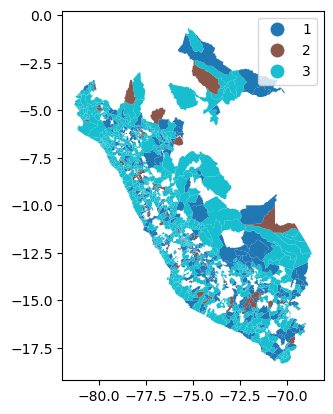

In [26]:
discrim.plot(column='eval',legend=True, categorical=True)

In [28]:
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1873
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   DEPARTAMEN     1393 non-null   object  
 1   PROVINCIA      1393 non-null   object  
 2   DISTRITO       1393 non-null   object  
 3   INSTITUCIO     1393 non-null   object  
 4   geometry       1393 non-null   geometry
 5   merger         1393 non-null   object  
 6   cod            1393 non-null   object  
 7   2015           1393 non-null   float64 
 8   2024           1393 non-null   float64 
 9   tasa2024_2015  1393 non-null   float64 
 10  eval           1393 non-null   int64   
 11  outlierTasa    1393 non-null   bool    
dtypes: bool(1), float64(3), geometry(1), int64(1), object(6)
memory usage: 132.0+ KB


In [29]:
discrim.rename(columns={'eval':'tasa_grupo'},inplace=True)
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1873
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   DEPARTAMEN     1393 non-null   object  
 1   PROVINCIA      1393 non-null   object  
 2   DISTRITO       1393 non-null   object  
 3   INSTITUCIO     1393 non-null   object  
 4   geometry       1393 non-null   geometry
 5   merger         1393 non-null   object  
 6   cod            1393 non-null   object  
 7   2015           1393 non-null   float64 
 8   2024           1393 non-null   float64 
 9   tasa2024_2015  1393 non-null   float64 
 10  tasa_grupo     1393 non-null   int64   
 11  outlierTasa    1393 non-null   bool    
dtypes: bool(1), float64(3), geometry(1), int64(1), object(6)
memory usage: 132.0+ KB


In [30]:
from libpysal.weights import KNN
from esda.moran import Moran

w_knn8 = KNN.from_dataframe(discrim, k=8)
w_knn8.transform = 'R'


moranTasa = Moran(discrim['ratio2024_2015'], w_knn8)
moranTasa.I,moranTasa.p_sim

(0.03295897265147944, 0.013)

In [31]:
from esda.moran import Moran_Local
labels = [ '0 no_sig', '1 hotSpot', '2 coldOutlier', '3 coldSpot', '4 hotOutlier']

lisaTasa = Moran_Local(y=discrim['ratio2024_2015'], w=w_knn8,seed=2022)
discrim['Tasa_quadrant']=[l if p <0.05 else 0 for l,p in zip(lisaTasa.q,lisaTasa.p_sim)  ]


discrim['Tasa_quadrant_names']=[labels[i] for i in discrim['Tasa_quadrant']]

discrim['Tasa_quadrant_names'].value_counts()

0 no_sig         1156
3 coldSpot        140
2 coldOutlier      65
4 hotOutlier       16
1 hotSpot          16
Name: Tasa_quadrant_names, dtype: int64

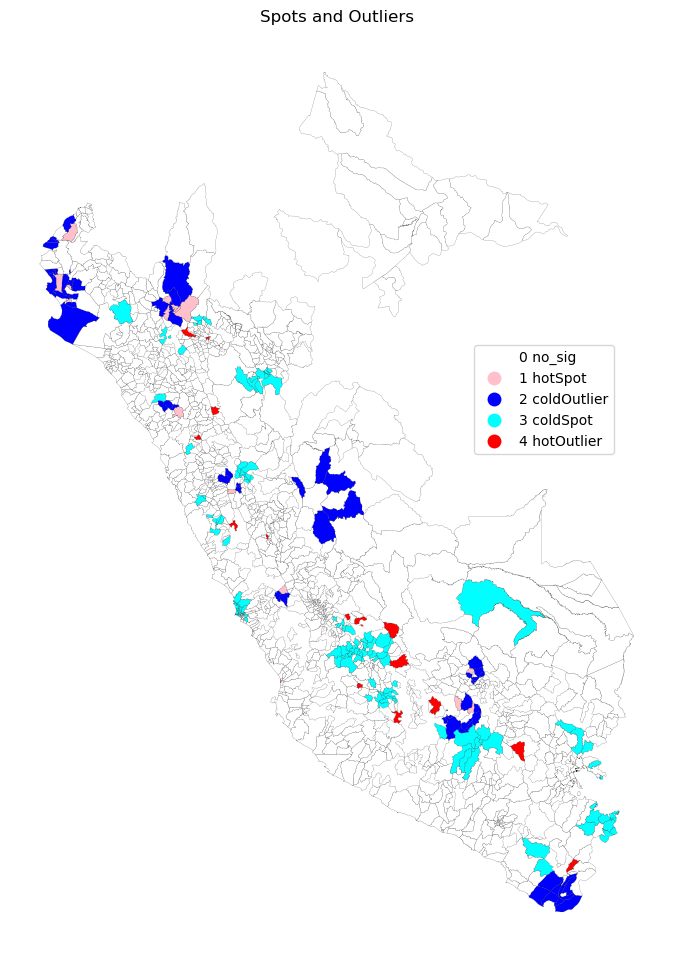

In [32]:
# custom colors
from matplotlib import pyplot as plt
from matplotlib import colors
myColMap = colors.ListedColormap([ 'white', 'pink', 'blue', 'cyan','red'])

# Set up figure and ax
f, ax = plt.subplots(1, figsize=(12,12))
# Plot unique values choropleth including
# a legend and with no boundary lines

plt.title('Spots and Outliers')

discrim.plot(column='Tasa_quadrant_names', 
                categorical=True,
                cmap=myColMap,
                linewidth=0.1, 
                edgecolor='k',
                legend=True,
                legend_kwds={'loc': 'center left', 
                             'bbox_to_anchor': (0.7, 0.6)},
                ax=ax)
# Remove axis
ax.set_axis_off()
# Display the map
plt.show()

In [33]:
peruBorder=dis.dissolve()

In [34]:
peruBorder.to_file('distritos.gpkg', driver='GPKG', layer='border') 

In [35]:
discrim.rename(columns={'2024':'denun2024','2015':'denun2015'},inplace=True)
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1873
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   DEPARTAMEN           1393 non-null   object  
 1   PROVINCIA            1393 non-null   object  
 2   DISTRITO             1393 non-null   object  
 3   INSTITUCIO           1393 non-null   object  
 4   geometry             1393 non-null   geometry
 5   merger               1393 non-null   object  
 6   cod                  1393 non-null   object  
 7   denun2015            1393 non-null   float64 
 8   denun2024            1393 non-null   float64 
 9   tasa2024_2015        1393 non-null   float64 
 10  tasa_grupo           1393 non-null   int64   
 11  outlierTasa          1393 non-null   bool    
 12  Tasa_quadrant        1393 non-null   int64   
 13  Tasa_quadrant_names  1393 non-null   object  
dtypes: bool(1), float64(3), geometry(1), int64(2), object(7)
memory 

In [36]:
discrim['dif2024_2015']=discrim.denun2024-discrim.denun2015

In [37]:
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1873
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   DEPARTAMEN           1393 non-null   object  
 1   PROVINCIA            1393 non-null   object  
 2   DISTRITO             1393 non-null   object  
 3   INSTITUCIO           1393 non-null   object  
 4   geometry             1393 non-null   geometry
 5   merger               1393 non-null   object  
 6   cod                  1393 non-null   object  
 7   denun2015            1393 non-null   float64 
 8   denun2024            1393 non-null   float64 
 9   tasa2024_2015        1393 non-null   float64 
 10  tasa_grupo           1393 non-null   int64   
 11  outlierTasa          1393 non-null   bool    
 12  Tasa_quadrant        1393 non-null   int64   
 13  Tasa_quadrant_names  1393 non-null   object  
 14  dif2024_2015         1393 non-null   float64 
dtypes: bool(1), f

In [38]:
discrim.columns

Index(['DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'INSTITUCIO', 'geometry',
       'merger', 'cod', 'denun2015', 'denun2024', 'tasa2024_2015',
       'tasa_grupo', 'outlierTasa', 'Tasa_quadrant', 'Tasa_quadrant_names',
       'dif2024_2015'],
      dtype='object')

In [39]:
discrim=discrim.loc[:,['DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'INSTITUCIO', 'merger', 'cod',
       'denun2015', 'denun2024', 'dif2024_2015','ratio2024_2015', 'tasa_grupo', 'outlierTasa',
       'Tasa_quadrant', 'Tasa_quadrant_names', 'geometry']]
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1873
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   DEPARTAMEN           1393 non-null   object  
 1   PROVINCIA            1393 non-null   object  
 2   DISTRITO             1393 non-null   object  
 3   INSTITUCIO           1393 non-null   object  
 4   merger               1393 non-null   object  
 5   cod                  1393 non-null   object  
 6   denun2015            1393 non-null   float64 
 7   denun2024            1393 non-null   float64 
 8   dif2024_2015         1393 non-null   float64 
 9   tasa2024_2015        1393 non-null   float64 
 10  tasa_grupo           1393 non-null   int64   
 11  outlierTasa          1393 non-null   bool    
 12  Tasa_quadrant        1393 non-null   int64   
 13  Tasa_quadrant_names  1393 non-null   object  
 14  geometry             1393 non-null   geometry
dtypes: bool(1), f

<Axes: >

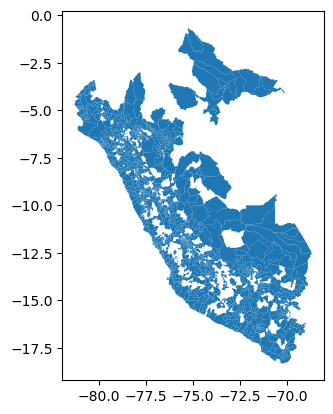

In [40]:
discrim.plot()

In [41]:
import mapclassify
ht=mapclassify.HeadTailBreaks(discrim["ratio2024_2015"])
ht

HeadTailBreaks

    Interval       Count
------------------------
[  0.05,   2.97] |  1119
(  2.97,  10.05] |   227
( 10.05,  35.56] |    37
( 35.56, 100.35] |     7
(100.35, 221.50] |     2
(221.50, 339.50] |     1

In [42]:
qt=mapclassify.Quantiles(discrim["ratio2024_2015"])
qt

Quantiles

    Interval       Count
------------------------
[  0.05,   0.67] |   283
(  0.67,   1.14] |   274
(  1.14,   1.70] |   279
(  1.70,   2.88] |   278
(  2.88, 339.50] |   279

In [43]:
bp=mapclassify.BoxPlot(discrim["ratio2024_2015"])
bp

BoxPlot

    Interval       Count
------------------------
(  -inf,  -1.55] |     0
( -1.55,   0.81] |   349
(  0.81,   1.40] |   351
(  1.40,   2.38] |   345
(  2.38,   4.74] |   213
(  4.74, 339.50] |   135

In [44]:
ei=mapclassify.EqualInterval(discrim["ratio2024_2015"], k=5)
ei

EqualInterval

    Interval       Count
------------------------
[  0.05,  67.94] |  1389
( 67.94, 135.83] |     1
(135.83, 203.72] |     2
(203.72, 271.61] |     0
(271.61, 339.50] |     1

In [45]:
discrim['ratio_qt']=qt.yb
discrim['ratio_atip']=bp.yb
discrim['ratio_autoGrup']=ht.yb
discrim['ratio_igualInter']=ei.yb


In [47]:
pops=pd.read_excel("conteoVivHogPob.xlsx",dtype={'cod': str})
pops

,cod,distrito,Vivienda,Hogar,Población
0,010101,CHACHAPOYAS,9664,8437,32589
1,010102,ASUNCIÓN,141,105,262
2,010103,BALSAS,619,359,1136
3,010104,CHETO,337,220,642
4,010105,CHILIQUIN,308,206,585
...,...,...,...,...,...
1869,250302,IRAZOLA,3837,2580,10214
1870,250303,CURIMANA,2403,1890,7722
1871,250304,NESHUYA,2356,1932,7594
1872,250305,ALEXANDER VON HUMBOLDT,1856,1302,5137


In [48]:
discrim=discrim.merge(pops,on='cod')
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1392
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   DEPARTAMEN           1393 non-null   object  
 1   PROVINCIA            1393 non-null   object  
 2   DISTRITO             1393 non-null   object  
 3   INSTITUCIO           1393 non-null   object  
 4   merger               1393 non-null   object  
 5   cod                  1393 non-null   object  
 6   denun2015            1393 non-null   float64 
 7   denun2024            1393 non-null   float64 
 8   dif2024_2015         1393 non-null   float64 
 9   tasa2024_2015        1393 non-null   float64 
 10  tasa_grupo           1393 non-null   int64   
 11  outlierTasa          1393 non-null   bool    
 12  Tasa_quadrant        1393 non-null   int64   
 13  Tasa_quadrant_names  1393 non-null   object  
 14  geometry             1393 non-null   geometry
 15  tasa_qt      

In [49]:
discrim.columns

Index(['DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'INSTITUCIO', 'merger', 'cod',
       'denun2015', 'denun2024', 'dif2024_2015', 'tasa2024_2015', 'tasa_grupo',
       'outlierTasa', 'Tasa_quadrant', 'Tasa_quadrant_names', 'geometry',
       'tasa_qt', 'tasa_atip', 'tasa_autoGrup', 'tasa_igualInter', 'distrito',
       'Vivienda', 'Hogar', 'Población'],
      dtype='object')

In [51]:
discrim=discrim.loc[:,['DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'INSTITUCIO', 'merger', 'cod',
       'denun2015', 'denun2024', 'dif2024_2015', 'ratio2024_2015', 'ratio_grupo',
       'outlierratio', 'ratio_quadrant', 'ratio_quadrant_names',
       'ratio_qt', 'ratio_atip', 'ratio_autoGrup', 'ratio_igualInter', 
       'Vivienda', 'Hogar', 'Población','geometry']]
discrim.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1393 entries, 0 to 1392
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   DEPARTAMEN           1393 non-null   object  
 1   PROVINCIA            1393 non-null   object  
 2   DISTRITO             1393 non-null   object  
 3   INSTITUCIO           1393 non-null   object  
 4   merger               1393 non-null   object  
 5   cod                  1393 non-null   object  
 6   denun2015            1393 non-null   float64 
 7   denun2024            1393 non-null   float64 
 8   dif2024_2015         1393 non-null   float64 
 9   tasa2024_2015        1393 non-null   float64 
 10  tasa_grupo           1393 non-null   int64   
 11  outlierTasa          1393 non-null   bool    
 12  Tasa_quadrant        1393 non-null   int64   
 13  Tasa_quadrant_names  1393 non-null   object  
 14  tasa_qt              1393 non-null   int64   
 15  tasa_atip    

<Axes: >

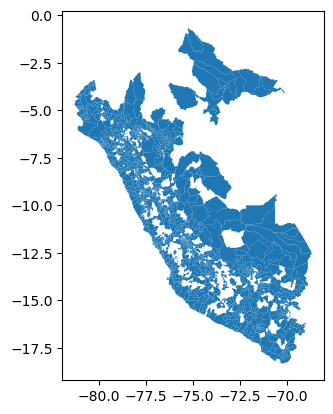

In [52]:
discrim.plot()

In [53]:
discrim.to_file('distritos.gpkg', driver='GPKG', layer='crimen') 